# Exploratory Data Analysis: Exoplanet Hunting using Time-Series Data

## Abstract
This notebook constitutes the initial phase of the Exoplanet Hunting Machine Learning project. The primary objective is to detect exoplanets utilizing the **Transit Photometry** method by analyzing time-series data (light curves) obtained from space telescopes. When an exoplanet crosses in front of its host star, it causes a periodic dip in the star's apparent brightness (flux). 

## Objectives of this Notebook
1. **Data Ingestion:** Load the raw observation data, which is split into three separate components: Time dimensions (`Astro_Time_data`), Flux intensities (`Astro_Flux_data`), and pre-calculated statistical metadata (`features_dataset`).
2. **Data Alignment & Integrity Check:** Resolve dimensional inconsistencies (row/column mismatches) between the time and flux arrays to ensure symmetrical matrix shapes required for Machine Learning pipelines.
3. **Imputation:** Identify and handle missing values (`NaN`s) caused by telescope recalibrations or signal loss using **Linear Interpolation**, preparing the raw signal for Frequency Domain transformation (FFT).
4. **Visual Inspection:** Reconstruct and plot the light curves to visually differentiate between stars with confirmed exoplanets (Class 1) and stars without (Class 0), analyzing the background stellar noise and transit depths.

## Target Metric & Class Distribution
Initial exploration confirms a balanced dataset (~50/50 split between Class 0 and Class 1), eliminating the immediate need for extreme oversampling techniques (e.g., SMOTE). The baseline evaluation metric will focus on **Accuracy** and **Recall** (to minimize false negatives in astronomical discoveries).

# Step 1: Environment Setup

In [ ]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

import warnings
warnings.filterwarnings('ignore') 

# Step 2: Data Loading & Garbage Removal

In [2]:
url_astro_flux_data = "../data/raw/Astro_Flux_data.csv"
url_astro_time_data = "../data/raw/Astro_Time_data.csv"
url_features_dataset = "../data/raw/features_dataset.csv"

In [12]:
df_astro_flux = pd.read_csv(url_astro_flux_data)
df_astro_flux.head()

,Unnamed: 0,id,class,flux_1,flux_2,flux_3,flux_4,flux_5,flux_6,flux_7,...,flux_4601,flux_4602,flux_4603,flux_4604,flux_4605,flux_4606,flux_4607,flux_4608,flux_4609,flux_4610
0,0,1162345,0,1.000004,0.999888,0.999851,0.999702,0.999504,0.999597,0.999599,...,0.999682,0.999712,0.999672,0.999617,0.999411,0.999666,0.999774,0.999882,0,1162345
1,1,1292087,0,1.000004,1.000311,1.000075,1.000127,1.000006,0.999997,0.999994,...,1.000142,1.000149,1.000085,1.000140,1.000033,1.000244,1.000168,1.000115,0,1292087
2,2,1293031,0,0.999905,1.000255,0.999938,1.000197,1.000316,1.000329,1.000266,...,1.000313,0.999914,1.000215,1.000259,0.999771,1.000151,1.000196,1.000142,0,1293031
3,3,1162345,0,1.000004,0.999888,0.999851,0.999702,0.999504,0.999597,0.999599,...,0.999682,0.999712,0.999672,0.999617,0.999411,0.999666,0.999774,0.999882,0,1162345
4,4,1164109,0,0.999244,0.999332,0.999262,0.999323,0.999352,0.999310,0.999296,...,1.000818,1.000740,1.000780,1.000757,1.000723,1.000726,1.000733,1.000783,0,1164109


In [13]:
df_astro_flux.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Columns: 4613 entries, Unnamed: 0 to flux_4610
dtypes: float64(4608), int64(5)
memory usage: 211.2 MB


In [14]:
df_astro_time_data = pd.read_csv(url_astro_time_data)
df_astro_time_data.head()

,Unnamed: 0,id,class,time_1,time_2,time_3,time_4,time_5,time_6,time_7,...,time_4599,time_4600,time_4601,time_4602,time_4603,time_4604,time_4605,time_4606,time_4607,time_4608
0,0,1162345,0,0.040869,0.061303,0.081738,0.102172,0.122606,0.143041,0.163475,...,97.207175,97.227609,97.248043,97.268478,97.288912,97.309346,97.329781,97.350215,97.370649,97.391084
1,1,1292087,0,0.040869,0.061303,0.081738,0.102172,0.122606,0.143041,0.163475,...,97.207148,97.227582,97.248016,97.268450,97.288885,97.309319,97.329753,97.350188,97.370622,97.391056
2,2,1293031,0,0.040869,0.061303,0.081738,0.102172,0.122606,0.143041,0.163475,...,97.207162,97.227596,97.248031,97.268465,97.288899,97.309334,97.329768,97.350202,97.370636,97.391071
3,3,1162345,0,0.040869,0.061303,0.081738,0.102172,0.122606,0.143041,0.163475,...,97.207175,97.227609,97.248043,97.268478,97.288912,97.309346,97.329781,97.350215,97.370649,97.391084
4,4,1164109,0,0.040869,0.061303,0.081738,0.102172,0.122606,0.143041,0.163475,...,97.207180,97.227614,97.248048,97.268483,97.288917,97.309351,97.329786,97.350220,97.370654,97.391089


In [15]:
df_astro_time_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Columns: 4611 entries, Unnamed: 0 to time_4608
dtypes: float64(4608), int64(3)
memory usage: 211.1 MB


In [16]:
df_features_dataset = pd.read_csv(url_features_dataset)
df_features_dataset.head()

,Unnamed: 0.38,Unnamed: 0.37,Unnamed: 0.36,Unnamed: 0.35,Unnamed: 0.34,Unnamed: 0.33,Unnamed: 0.32,Unnamed: 0.31,Unnamed: 0.30,Unnamed: 0.29,...,flux__fourier_entropy__bins_10,flux__fourier_entropy__bins_100,flux__permutation_entropy__dimension_3__tau_1,flux__permutation_entropy__dimension_4__tau_1,flux__permutation_entropy__dimension_5__tau_1,flux__permutation_entropy__dimension_6__tau_1,flux__permutation_entropy__dimension_7__tau_1,flux__mean_n_absolute_max__number_of_maxima_7,id,class
0,0,0,0,0,0,0,0,0,0,0,...,0.503511,1.557855,1.765625,3.071839,4.532915,6.061455,7.334390,1.001358,1162345,0
1,1,1,1,1,1,1,1,1,1,1,...,0.170467,1.260680,1.789681,3.168145,4.751323,6.443841,7.829797,1.000834,1292087,0
2,2,2,2,2,2,2,2,2,2,2,...,0.181214,1.547269,1.788882,3.165032,4.745574,6.435598,7.823533,1.001417,1293031,0
3,3,3,3,3,3,3,3,3,3,3,...,0.503511,1.557855,1.765625,3.071839,4.532915,6.061455,7.334390,1.001358,1162345,0
4,4,4,4,4,4,4,4,4,4,4,...,0.136002,0.226363,1.779898,3.114779,4.602898,6.145392,7.365984,1.002441,1164109,0


In [17]:
df_features_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5899 entries, 0 to 5898
Columns: 823 entries, Unnamed: 0.38 to class
dtypes: float64(782), int64(41)
memory usage: 37.0 MB


### Cleaned Data Astro flux data

In [20]:
cols_to_drop = [col for col in df_astro_flux.columns if 'Unnamed' in col]
print(f"Columns for Drop: {cols_to_drop}")

df_astro_flux_cleaned = df_astro_flux.drop(cols_to_drop, axis=1)

Columns for Drop: ['Unnamed: 0']


In [21]:
print(f"Original shape: {df_astro_flux.shape}")
print(f"Cleaned shape: {df_astro_flux_cleaned.shape}")

Original shape: (6000, 4613)
Cleaned shape: (6000, 4612)


### Cleaned Astro Time data

In [22]:
cols_to_drop = [col for col in df_astro_time_data.columns if 'Unnamed' in col]
print(f"Columns for Drop: {cols_to_drop}")

df_astro_time_data_cleaned = df_astro_time_data.drop(cols_to_drop, axis=1)

Columns for Drop: ['Unnamed: 0']


In [23]:
print(f"Original shape: {df_astro_time_data.shape}")
print(f"Cleaned shape: {df_astro_time_data_cleaned.shape}")

Original shape: (6000, 4611)
Cleaned shape: (6000, 4610)


### Cleaned Features Dataset

In [25]:
cols_to_drop = [col for col in df_features_dataset.columns if 'Unnamed' in col]
print(f"Columns for Drop: {cols_to_drop}")

df_features_dataset_cleaned = df_features_dataset.drop(cols_to_drop, axis=1)

Columns for Drop: ['Unnamed: 0.38', 'Unnamed: 0.37', 'Unnamed: 0.36', 'Unnamed: 0.35', 'Unnamed: 0.34', 'Unnamed: 0.33', 'Unnamed: 0.32', 'Unnamed: 0.31', 'Unnamed: 0.30', 'Unnamed: 0.29', 'Unnamed: 0.28', 'Unnamed: 0.27', 'Unnamed: 0.26', 'Unnamed: 0.25', 'Unnamed: 0.24', 'Unnamed: 0.23', 'Unnamed: 0.22', 'Unnamed: 0.21', 'Unnamed: 0.20', 'Unnamed: 0.19', 'Unnamed: 0.18', 'Unnamed: 0.17', 'Unnamed: 0.16', 'Unnamed: 0.15', 'Unnamed: 0.14', 'Unnamed: 0.13', 'Unnamed: 0.12', 'Unnamed: 0.11', 'Unnamed: 0.10', 'Unnamed: 0.9', 'Unnamed: 0.8', 'Unnamed: 0.7', 'Unnamed: 0.6', 'Unnamed: 0.5', 'Unnamed: 0.4', 'Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0']


In [27]:
print(f"Original shape: {df_features_dataset.shape}")
print(f"Cleaned shape: {df_features_dataset_cleaned.shape}")

Original shape: (5899, 823)
Cleaned shape: (5899, 784)


# Step 3: Class Imbalance Check

## Data Alignment

In [ ]:
# 1. Line-by-line synchronization (Inner Join logic)
# Only the stars (ids) that are in the dataset with the attributes are left in the raw data.
valid_ids = df_features_dataset_cleaned['id']

df_astro_flux_aligned = df_astro_flux_cleaned[df_astro_flux_cleaned['id'].isin(valid_ids)].copy()
df_astro_time_aligned = df_astro_time_data_cleaned[df_astro_time_data_cleaned['id'].isin(valid_ids)].copy()

# Resetting indexes so that they match in all tables
df_astro_flux_aligned.reset_index(drop=True, inplace=True)
df_astro_time_aligned.reset_index(drop=True, inplace=True)
df_features_dataset_cleaned.reset_index(drop=True, inplace=True)

# 2. Cutting off extra stream columns (Truncation)
# need to remove flux_4609 and flux_4610 so that the length matches the time (4608 steps)
cols_to_drop_flux = ['flux_4609', 'flux_4610']
df_astro_flux_aligned.drop(columns=cols_to_drop_flux, inplace=True, errors='ignore')

print(f"Aligned Flux shape: {df_astro_flux_aligned.shape}")
print(f"Aligned Time shape: {df_astro_time_aligned.shape}")

Aligned Flux shape: (5899, 4610)
Aligned Time shape: (5899, 4610)


### Target Distribution

In [ ]:
class_counts = df_features_dataset_cleaned['class'].value_counts()
class_ratio = df_features_dataset_cleaned['class'].value_counts(normalize=True) * 100

print("Absolute counts:\n", class_counts)
print("\nPercentage:\n", class_ratio)

Absolute counts:
 class
0    3000
1    2899
Name: count, dtype: int64

Percentage:
 class
0    50.856077
1    49.143923
Name: proportion, dtype: float64


<Axes: xlabel='class', ylabel='count'>

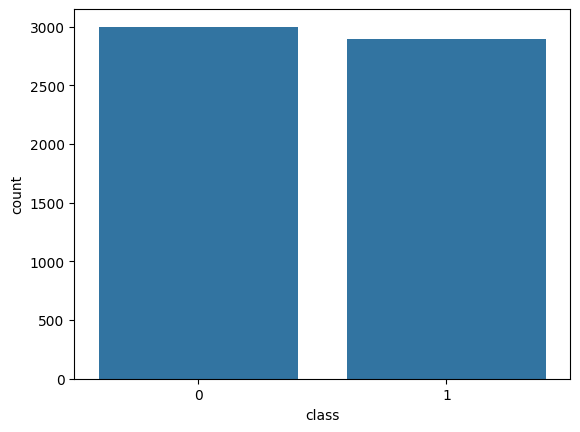

In [34]:
sns.countplot(data=df_features_dataset_cleaned, x='class')

# Step 4: Time Series Reconstruction & Plotting

Plotting Class 0 (No Planet):


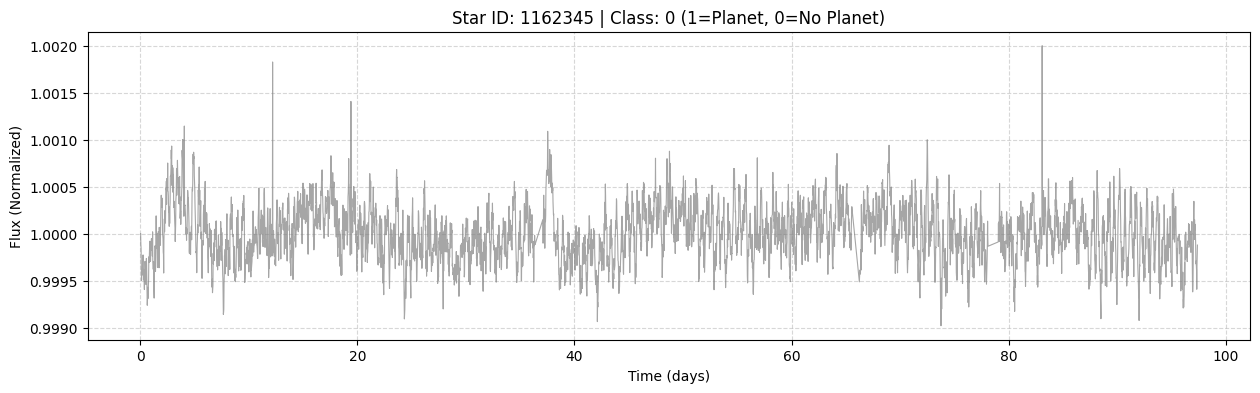

Plotting Class 1 (Confirmed Planet):


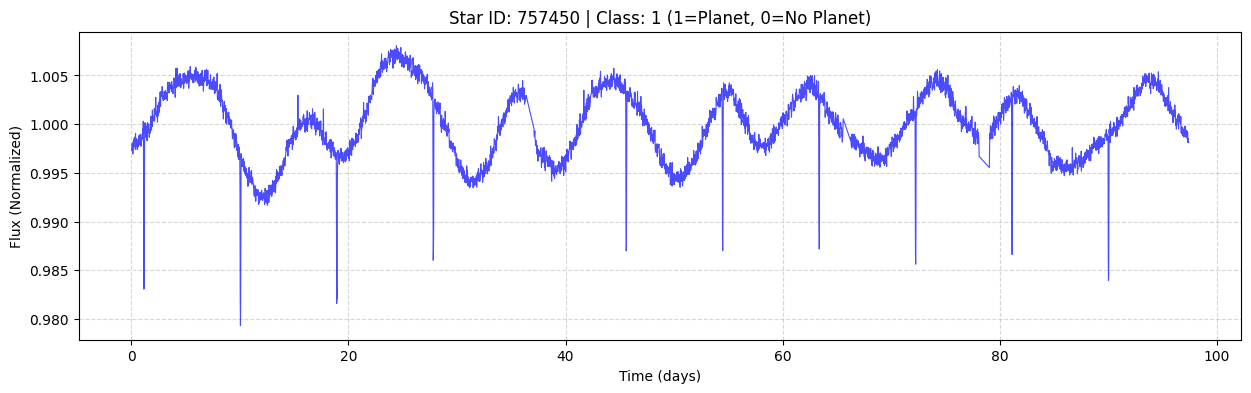

In [35]:
def plot_light_curve(row_idx, time_df, flux_df):
    """
    Extracts and plots a light curve for a specific row (star).
    """
    # Extracting the label
    target_class = time_df['class'].iloc[row_idx]
    star_id = time_df['id'].iloc[row_idx]
    
    # Drop the "identifier" and "class", leaving only the values of the time series.
    time_vals = time_df.drop(columns=['id', 'class']).iloc[row_idx].values
    flux_vals = flux_df.drop(columns=['id', 'class']).iloc[row_idx].values
    
    # Visualization
    plt.figure(figsize=(15, 4))
    plt.plot(time_vals, flux_vals, color='b' if target_class == 1 else 'gray', alpha=0.7, linewidth=0.8)
    plt.title(f"Star ID: {star_id} | Class: {target_class} (1=Planet, 0=No Planet)")
    plt.xlabel("Time (days)")
    plt.ylabel("Flux (Normalized)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Find the indexes for the first available class 0 and class 1
idx_class_0 = df_astro_time_aligned[df_astro_time_aligned['class'] == 0].index[0]
idx_class_1 = df_astro_time_aligned[df_astro_time_aligned['class'] == 1].index[0]

# Building graphs
print("Plotting Class 0 (No Planet):")
plot_light_curve(idx_class_0, df_astro_time_aligned, df_astro_flux_aligned)

print("Plotting Class 1 (Confirmed Planet):")
plot_light_curve(idx_class_1, df_astro_time_aligned, df_astro_flux_aligned)

In [ ]:
# Calculating the total number of passes in synchronized arrays
flux_nans = df_astro_flux_aligned.isna().sum().sum()
time_nans = df_astro_time_aligned.isna().sum().sum()
features_nans = df_features_dataset_cleaned.isna().sum().sum()

print(f"Total NaNs in Flux: {flux_nans}")
print(f"Total NaNs in Time: {time_nans}")
print(f"Total NaNs in Features: {features_nans}")

Total NaNs in Flux: 74269
Total NaNs in Time: 74269
Total NaNs in Features: 0


The amount of missing data (NaN) is 74,269 values, which is ≈ 27.1 million points for a total dataset size of 5899 (stars) × 4608 (time steps). 
corresponds to only ~0.27%. This is a small fraction, typical for astronomical observations (signal loss, equipment calibration).

# Step 5: Data Imputation

In [39]:
# Filling NaN with linear line-by-line interpolation (axis=1), 
# limit_direction='both' will fill in the voids even if they are at the very edges (at the beginning or end)
df_astro_flux_aligned = df_astro_flux_aligned.interpolate(method='linear', axis=1, limit_direction='both')
df_astro_time_aligned = df_astro_time_aligned.interpolate(method='linear', axis=1, limit_direction='both')

# Check
print("Remaining NaNs in Flux:", df_astro_flux_aligned.isna().sum().sum())
print("Remaining NaNs in Time:", df_astro_time_aligned.isna().sum().sum())

Remaining NaNs in Flux: 0
Remaining NaNs in Time: 0


# Save the cleared data to a folder

In [40]:
# Saving the cleared data for the next stage (Feature Engineering)
df_astro_flux_aligned.to_csv("../data/processed/clean_flux.csv", index=False)
df_astro_time_aligned.to_csv("../data/processed/clean_time.csv", index=False)
df_features_dataset_cleaned.to_csv("../data/processed/clean_features.csv", index=False)

print("Data successfully saved to /data/processed/")

Data successfully saved to /data/processed/
